In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

# Exercício

1. Gere uma amostra de tamanho $M$ de uma exponencial através do método de inversão visto em sala. Compare com uma exponencial gerada pelo numpy via histogramas. Comparem também com a densidade real da exponencial $f(x) = \lambda e^{-\lambda x}$ (isto é, seu histograma normalizado tem que ficar igual essa curva).

In [2]:
lbd = 10
M = 1000
U = np.random.uniform()
exp = (-1)*np.log(U)/lbd
print(exp)

0.4726425039714524


Aqui eu apenas utilizei o método da inversão para gerar uma exponencial

(array([505., 233., 132.,  58.,  33.,  20.,   8.,   4.,   5.,   2.]),
 array([3.46936067e-05, 6.62940521e-02, 1.32553410e-01, 1.98812769e-01,
        2.65072127e-01, 3.31331486e-01, 3.97590844e-01, 4.63850203e-01,
        5.30109561e-01, 5.96368920e-01, 6.62628278e-01]),
 <BarContainer object of 10 artists>)

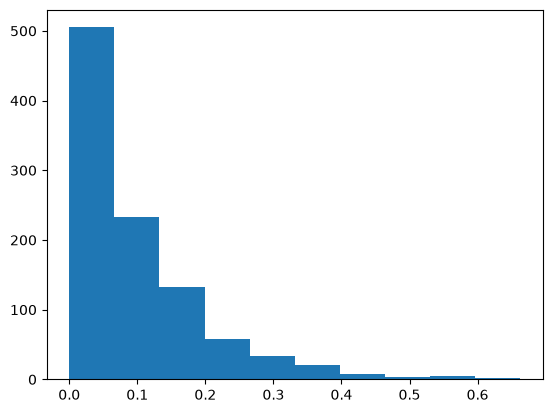

In [3]:
U = np.random.uniform(size=M)
exp = (-1)*np.log(U)/lbd

plt.hist(exp)
    

Aqui eu gerei uma amostra de exponenciais e fiz um histograma

(array([560., 253.,  96.,  56.,  15.,  12.,   7.,   0.,   0.,   1.]),
 array([1.72251321e-05, 8.06802488e-02, 1.61343272e-01, 2.42006296e-01,
        3.22669320e-01, 4.03332344e-01, 4.83995367e-01, 5.64658391e-01,
        6.45321415e-01, 7.25984438e-01, 8.06647462e-01]),
 <BarContainer object of 10 artists>)

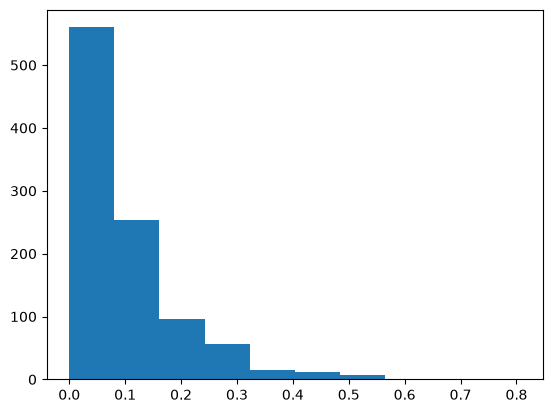

In [4]:
numpy = np.random.exponential(1/lbd, size=M)
plt.hist(numpy)

Aqui eu usei a própria função do python para gerar uma amostra exponencial, mas a parametrização dela considera a média como 1/lbd

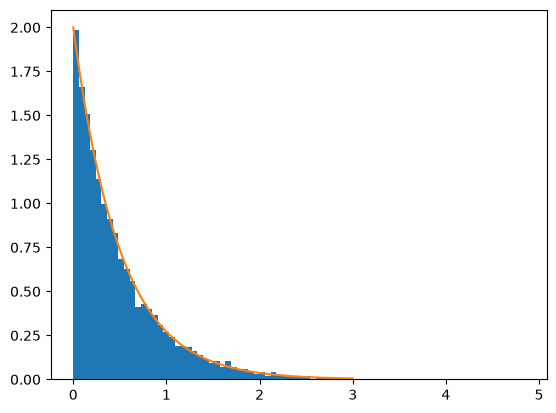

In [5]:
lamb = 2
x = np.linspace(0,3,10_000)
y = lamb*np.exp(-lamb*x)

amostra = np.random.exponential(1/lamb, size=10_000)

plt.hist(amostra, density=True, bins=80)
plt.plot(x,y)

Aqui eu só comparei o gráfico gerado pelas amostras de de exponenciais com a função de distribuição da exponencial

2. Agora considere $T_n = X_n / n$ onde $X_n$ é uma Geométrica com parâmetro $\lambda/n$. Mostre que quando $n$ é grande, isso se aproxima de uma exponencial.

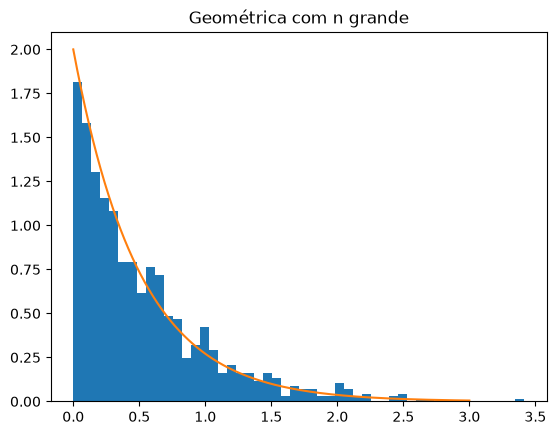

In [6]:
n = 10000
u = np.random.uniform(size=M)
Xn = np.ceil(np.log(u)/np.log(1-(lamb/n)))
Tn = Xn/n
plt.hist(Tn, density=True, bins=50)
plt.plot(x,y)
plt.title('Geométrica com n grande')
plt.show()

3. Considere agora $X_1, X_2, \ldots$ variáveis aleatórias i.i.d. com distribuição Exponencial de parâmetro $\lambda$. Vá somando essas variáveis até que a soma ultrapasse $1$ e conte quantas delas foram somadas antes de ultrapassar $1$. Repita esse procedimento $M$ vezes e mostre empiricamente que essa quantidade segue aproximadamente uma Poisson de parâmetro $\lambda$. Compare o histograma obtido com uma Poisson gerada pelo numpy e com a função de probabilidade real da Poisson.

In [7]:
unifs = np.random.uniform(size=(M,50))
exps = -np.log(unifs)/lamb
soma_acumulada = exps.cumsum(axis=1)

limite = soma_acumulada < 1
exponenciais_filtradas = np.where(limite, exps, 0)
contagem = np.where(exponenciais_filtradas != 0, 1, 0)

In [8]:
amostra_poisson = np.sum(contagem,axis=1)

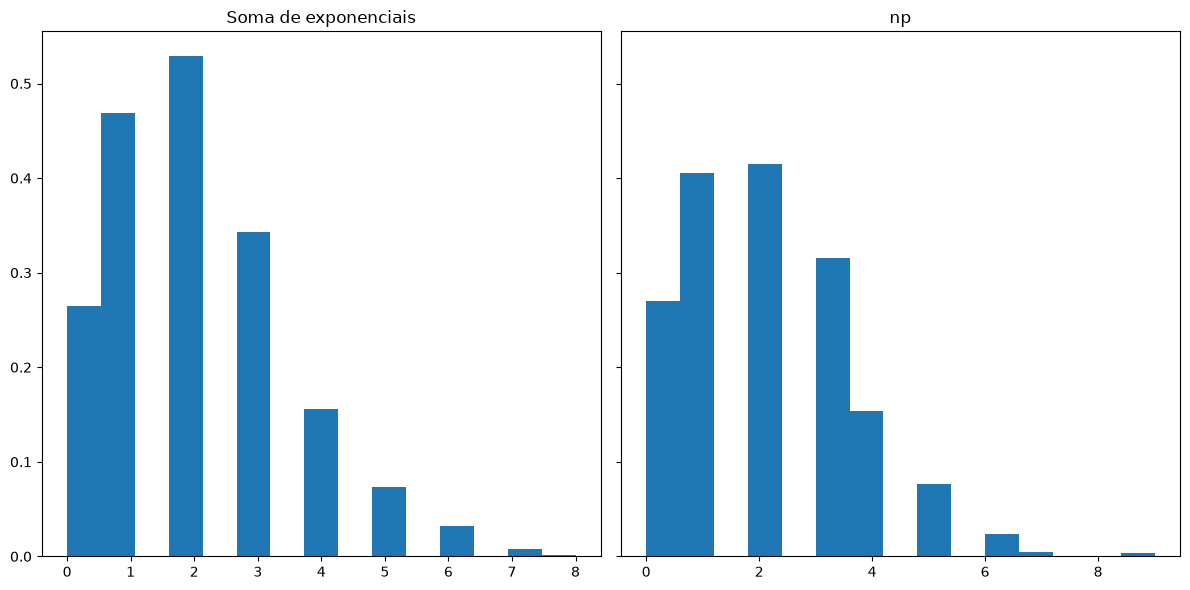

In [10]:
fig, ax = plt.subplots(1,2, figsize=(12,6), sharey=True)
ax[0].hist(amostra_poisson, density=True, bins=15)
ax[0].set_title('Soma de exponenciais')

ax[1].hist(np.random.poisson(lamb,size=M), density=True, bins = 15)
ax[1].set_title('np')
plt.tight_layout()
plt.show()